In [27]:
import cv2
import matplotlib.pyplot as plt

In [28]:
!ffmpeg -f avfoundation -list_devices true -i ""

ffmpeg version 7.1.1 Copyright (c) 2000-2025 the FFmpeg developers
  built with Apple clang version 16.0.0 (clang-1600.0.26.6)
  configuration: --prefix=/usr/local/Cellar/ffmpeg/7.1.1_2 --enable-shared --enable-pthreads --enable-version3 --cc=clang --host-cflags= --host-ldflags='-Wl,-ld_classic' --enable-ffplay --enable-gnutls --enable-gpl --enable-libaom --enable-libaribb24 --enable-libbluray --enable-libdav1d --enable-libharfbuzz --enable-libjxl --enable-libmp3lame --enable-libopus --enable-librav1e --enable-librist --enable-librubberband --enable-libsnappy --enable-libsrt --enable-libssh --enable-libsvtav1 --enable-libtesseract --enable-libtheora --enable-libvidstab --enable-libvmaf --enable-libvorbis --enable-libvpx --enable-libwebp --enable-libx264 --enable-libx265 --enable-libxml2 --enable-libxvid --enable-lzma --enable-libfontconfig --enable-libfreetype --enable-frei0r --enable-libass --enable-libopencore-amrnb --enable-libopencore-amrwb --enable-libopenjpeg --enable-libspeex --

In [29]:
!system_profiler SPCameraDataType

Camera:

    FaceTime HD-Kamera (integriert):

      Model ID: UVC Camera VendorID_1452 ProductID_34065
      Unique ID: 0x1460000005ac8511

    USB :

      Model ID: UVC Camera VendorID_3141 ProductID_25446
      Unique ID: 0x142114000c456366

    USB :

      Model ID: UVC Camera VendorID_3141 ProductID_25446
      Unique ID: 0x142112000c456366



In [30]:
# settings
exclude_cameras = [3] # e.g. connected iphone camera

In [32]:
def find_cameras():
    """Searches for available cameras and prints their properties"""
    cameras = []
    for index in range(4):
        if index in exclude_cameras:
            print(f"\nCamera {index}: excluded")
            continue

        cap = cv2.VideoCapture(index, cv2.CAP_AVFOUNDATION)

        if cap.isOpened():
            cameras.append(index)
            backend = cap.getBackendName()
            width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
            height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
            fps = cap.get(cv2.CAP_PROP_FPS)
            print(f"\nCamera {index}:")
            print(f"Backend: {backend}")
            print(f"Resolution: {width}x{height} - {fps:.2f} fps")
            cap.release()
        else:
            print(f"\nCamera {index}: not available")
    return cameras

cameras = find_cameras()



Camera 0:
Backend: AVFOUNDATION
Resolution: 1920x1080 - 25.00 fps

Camera 1:
Backend: AVFOUNDATION
Resolution: 1920x1080 - 25.00 fps

Camera 2:
Backend: AVFOUNDATION
Resolution: 1280x720 - 29.97 fps

Camera 3: excluded


Trying camera 0...


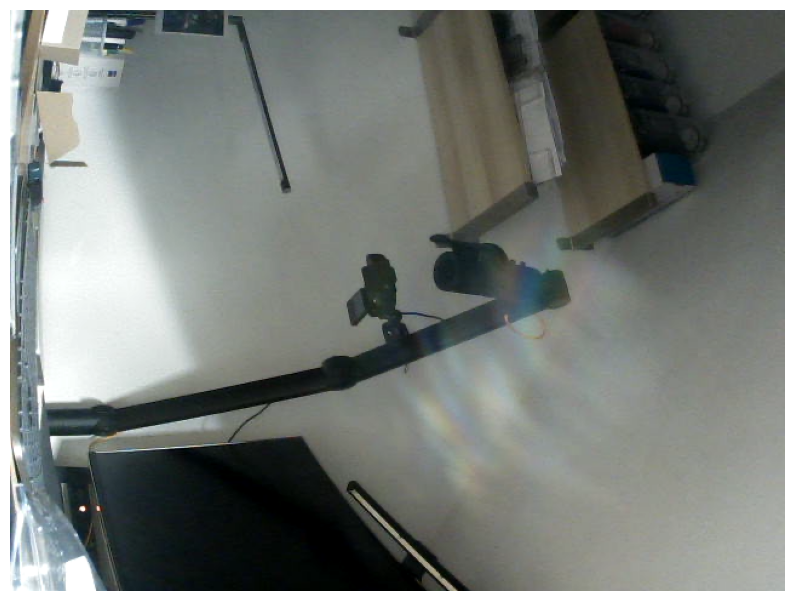

Trying camera 1...


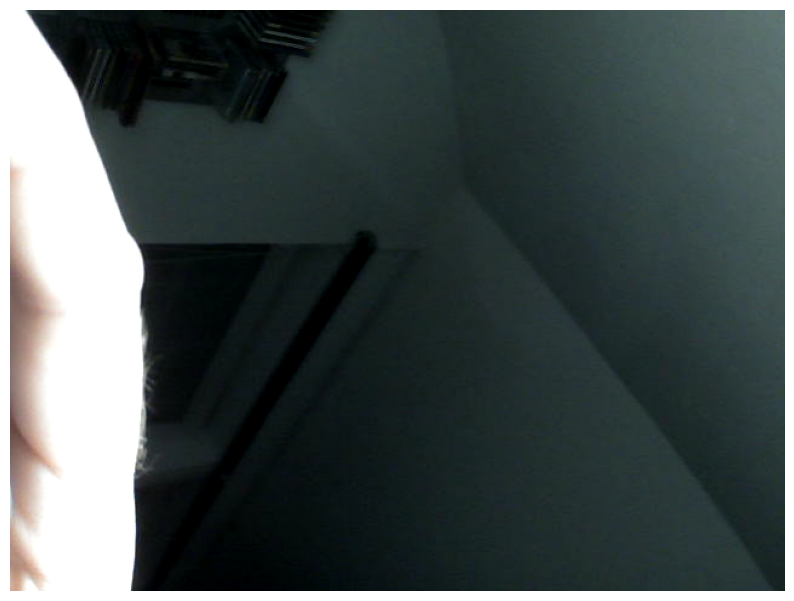

Trying camera 2...


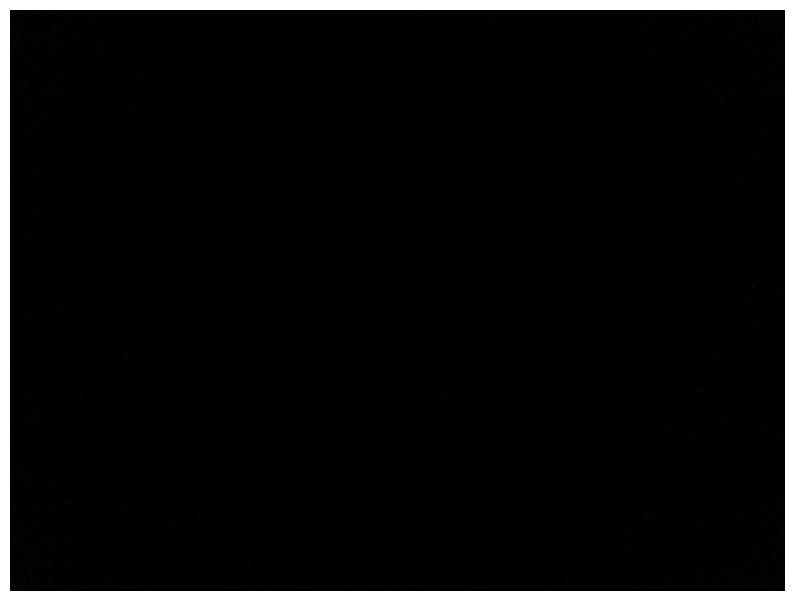

In [11]:
def show_camera_picture():
    """Takes a picture from the camera and displays it in the notebook"""

    for camera in cameras:
        print(f"Trying camera {camera}...")
        cap = cv2.VideoCapture(camera)
        if cap.isOpened():
            # Setze gewünschte Auflösung
            cap.set(cv2.CAP_PROP_FRAME_WIDTH, 640)
            cap.set(cv2.CAP_PROP_FRAME_HEIGHT, 480)

            # Versuche 30 fps
            cap.set(cv2.CAP_PROP_FPS, 30)
            ret, frame = cap.read()
            if ret:
                # OpenCV uses BGR, matplotlib expects RGB
                frame_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)

                # Display image with matplotlib
                plt.figure(figsize=(10, 8))
                plt.imshow(frame_rgb)
                plt.axis('off')  # Don't show axes
                plt.show()

            cap.release()
        else:
            print("Camera could not be opened")


# Take and display camera picture
show_camera_picture()


In [14]:
import pygame.camera

# initializing  the camera
pygame.camera.init()

# make the list of all available cameras
camlist = pygame.camera.list_cameras()

print(camlist)

pygame 2.6.1 (SDL 2.28.4, Python 3.10.11)
Hello from the pygame community. https://www.pygame.org/contribute.html
['FaceTime HD-Kamera (integriert)', 'USB ', 'USB ']
